In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv("customer_support_tickets_200k.csv")


In [3]:
df.head()


,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3,Corporate


In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 200000
Number of Columns: 30


In [5]:
df.columns

Index(['ticket_id', 'customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_age', 'customer_gender',
       'subscription_type', 'customer_tenure_months', 'previous_tickets',
       'customer_satisfaction_score', 'first_response_time_hours',
       'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date',
       'escalated', 'sla_breached', 'operating_system', 'browser',
       'payment_method', 'language', 'preferred_contact_time',
       'issue_complexity_score', 'customer_segment'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ticket_id                    200000 non-null  int64  
 1   customer_name                200000 non-null  object 
 2   customer_email               200000 non-null  object 
 3   product                      200000 non-null  object 
 4   category                     200000 non-null  object 
 5   issue_description            200000 non-null  object 
 6   resolution_notes             200000 non-null  object 
 7   priority                     200000 non-null  object 
 8   status                       200000 non-null  object 
 9   channel                      200000 non-null  object 
 10  region                       200000 non-null  object 
 11  customer_age                 200000 non-null  int64  
 12  customer_gender              200000 non-null  object 
 13 

In [7]:
# Count missing values in each column
df.isnull().sum()

ticket_id                          0
customer_name                      0
customer_email                     0
product                            0
category                           0
issue_description                  0
resolution_notes                   0
priority                           0
status                             0
channel                            0
region                             0
customer_age                       0
customer_gender                    0
subscription_type                  0
customer_tenure_months             0
previous_tickets                   0
customer_satisfaction_score        0
first_response_time_hours          0
resolution_time_hours              0
ticket_created_date                0
ticket_resolved_date               0
escalated                          0
sla_breached                       0
operating_system                   0
browser                        40023
payment_method                     0
language                           0
p

In [8]:
# To display only columns with missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

browser    40023
dtype: int64

In [9]:
df = df.drop('browser',axis=1)

In [10]:
df.isnull().sum()

ticket_id                      0
customer_name                  0
customer_email                 0
product                        0
category                       0
issue_description              0
resolution_notes               0
priority                       0
status                         0
channel                        0
region                         0
customer_age                   0
customer_gender                0
subscription_type              0
customer_tenure_months         0
previous_tickets               0
customer_satisfaction_score    0
first_response_time_hours      0
resolution_time_hours          0
ticket_created_date            0
ticket_resolved_date           0
escalated                      0
sla_breached                   0
operating_system               0
payment_method                 0
language                       0
preferred_contact_time         0
issue_complexity_score         0
customer_segment               0
dtype: int64

In [11]:
print(df.columns)

Index(['ticket_id', 'customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_age', 'customer_gender',
       'subscription_type', 'customer_tenure_months', 'previous_tickets',
       'customer_satisfaction_score', 'first_response_time_hours',
       'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date',
       'escalated', 'sla_breached', 'operating_system', 'payment_method',
       'language', 'preferred_contact_time', 'issue_complexity_score',
       'customer_segment'],
      dtype='object')


In [12]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

In [13]:
# Display duplicate rows
df[df.duplicated()]

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_created_date,ticket_resolved_date,escalated,sla_breached,operating_system,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment


In [14]:
print(df.columns)

Index(['ticket_id', 'customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_age', 'customer_gender',
       'subscription_type', 'customer_tenure_months', 'previous_tickets',
       'customer_satisfaction_score', 'first_response_time_hours',
       'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date',
       'escalated', 'sla_breached', 'operating_system', 'payment_method',
       'language', 'preferred_contact_time', 'issue_complexity_score',
       'customer_segment'],
      dtype='object')


In [15]:
# this has done to add the column 'Type' in the dataset 
type_mapping = {
"Account Suspension": "Request",
"Performance Issue": "Problem",
"Subscription Cancellation": "Request",
"Feature Request": "Request",
"Payment Problem": "Incident",
"Security Concern": "Incident",
"Refund Request": "Request",
"Login Issue": "Incident",
"Bug Report": "Incident"
}

In [16]:
df["Type"] = df["category"].map(type_mapping)

In [17]:
df[["category", "Type"]].head(10)

,category,Type
0,Account Suspension,Request
1,Performance Issue,Problem
2,Performance Issue,Problem
3,Subscription Cancellation,Request
4,Feature Request,Request
5,Payment Problem,Incident
6,Security Concern,Incident
7,Subscription Cancellation,Request
8,Security Concern,Incident
9,Performance Issue,Problem


In [18]:
df[df["Type"].isna()]["category"].unique()

array(['Data Sync Issue'], dtype=object)

In [19]:
df.to_csv("customer_support_tickets_updated.csv", index=False)

In [20]:
import os

print(os.getcwd())

C:\Users\ratho\infosys project\note book


In [21]:
df["category"].unique()

array(['Account Suspension', 'Performance Issue',
       'Subscription Cancellation', 'Feature Request', 'Payment Problem',
       'Security Concern', 'Refund Request', 'Login Issue', 'Bug Report',
       'Data Sync Issue'], dtype=object)

In [22]:
df[["category", "Type"]].head(20)

,category,Type
0,Account Suspension,Request
1,Performance Issue,Problem
2,Performance Issue,Problem
3,Subscription Cancellation,Request
4,Feature Request,Request
5,Payment Problem,Incident
6,Security Concern,Incident
7,Subscription Cancellation,Request
8,Security Concern,Incident
9,Performance Issue,Problem


In [23]:
df.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment,Type
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,PayPal,French,Afternoon,4,Small Business,Request
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,PayPal,English,Afternoon,2,Small Business,Problem
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Bank Transfer,French,Morning,4,Corporate,Problem
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Credit Card,Spanish,Afternoon,7,Corporate,Request
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,Debit Card,Spanish,Evening,3,Corporate,Request


In [24]:
df.columns.tolist()

['ticket_id',
 'customer_name',
 'customer_email',
 'product',
 'category',
 'issue_description',
 'resolution_notes',
 'priority',
 'status',
 'channel',
 'region',
 'customer_age',
 'customer_gender',
 'subscription_type',
 'customer_tenure_months',
 'previous_tickets',
 'customer_satisfaction_score',
 'first_response_time_hours',
 'resolution_time_hours',
 'ticket_created_date',
 'ticket_resolved_date',
 'escalated',
 'sla_breached',
 'operating_system',
 'payment_method',
 'language',
 'preferred_contact_time',
 'issue_complexity_score',
 'customer_segment',
 'Type']

In [25]:
df["Type"].head(20)

0      Request
1      Problem
2      Problem
3      Request
4      Request
5     Incident
6     Incident
7      Request
8     Incident
9      Problem
10     Request
11    Incident
12     Request
13     Request
14     Request
15     Request
16     Request
17     Request
18     Request
19    Incident
Name: Type, dtype: object

In [26]:
df["Type"].value_counts()

Type
Request     80029
Incident    80020
Problem     20074
Name: count, dtype: int64

In [27]:
# Count tickets by type
Type_distribution = df['Type'].value_counts()

print(Type_distribution)

Type
Request     80029
Incident    80020
Problem     20074
Name: count, dtype: int64


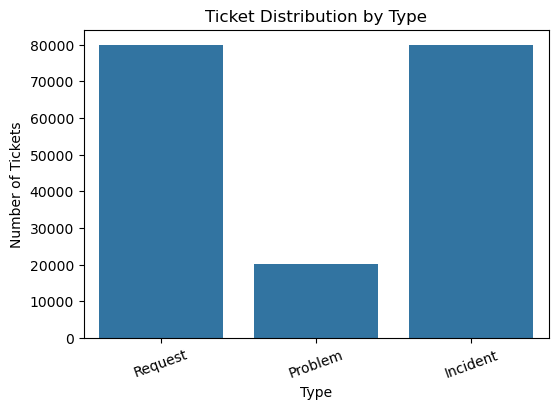

In [28]:

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Type')
plt.title('Ticket Distribution by Type')
plt.xlabel('Type')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=20)
plt.show()

In [29]:
# Count tickets by priority
priority_distribution = df['priority'].value_counts()

print(priority_distribution)

priority
High      50241
Urgent    50143
Medium    49854
Low       49762
Name: count, dtype: int64


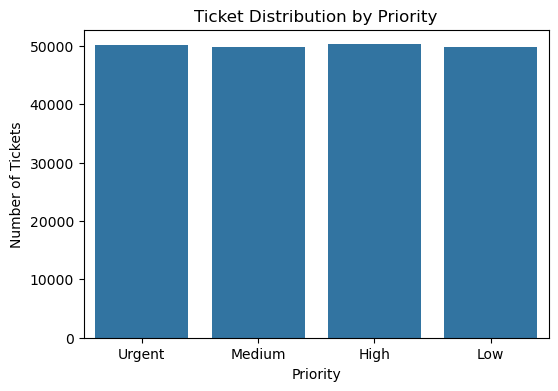

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='priority')
plt.title('Ticket Distribution by Priority')
plt.xlabel('Priority')
plt.ylabel('Number of Tickets')
plt.show()

In [31]:
# Count tickets by category
category_distribution = df['category'].value_counts()

print(category_distribution)

category
Feature Request              20169
Subscription Cancellation    20096
Performance Issue            20074
Security Concern             20040
Login Issue                  20002
Payment Problem              19997
Bug Report                   19981
Refund Request               19900
Data Sync Issue              19877
Account Suspension           19864
Name: count, dtype: int64


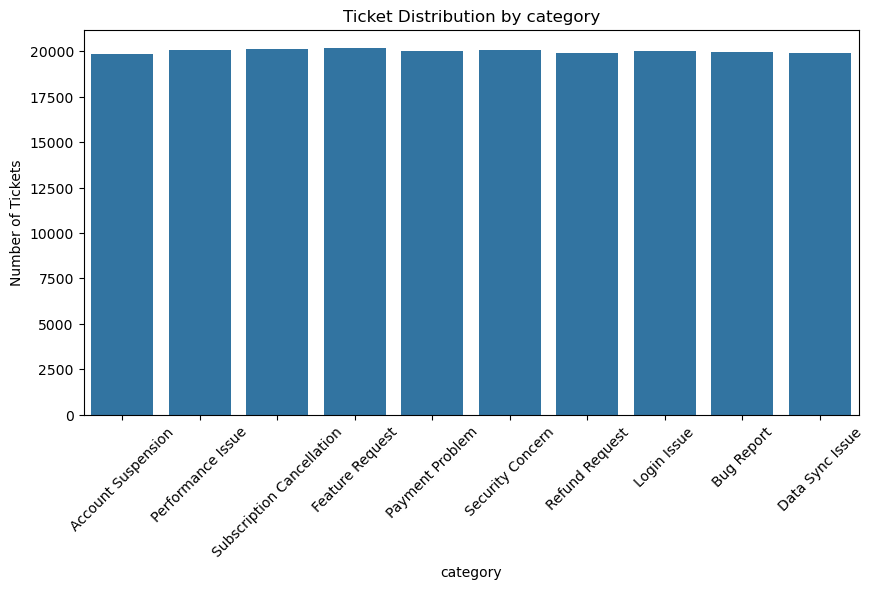

In [32]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='category')
plt.title('Ticket Distribution by category')
plt.xlabel('category')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.show()

In [33]:
# Check missing values in all columns
df.isnull().sum()

ticket_id                          0
customer_name                      0
customer_email                     0
product                            0
category                           0
issue_description                  0
resolution_notes                   0
priority                           0
status                             0
channel                            0
region                             0
customer_age                       0
customer_gender                    0
subscription_type                  0
customer_tenure_months             0
previous_tickets                   0
customer_satisfaction_score        0
first_response_time_hours          0
resolution_time_hours              0
ticket_created_date                0
ticket_resolved_date               0
escalated                          0
sla_breached                       0
operating_system                   0
payment_method                     0
language                           0
preferred_contact_time             0
i

In [34]:
text_columns = df.select_dtypes(include='object').columns
print(text_columns)

Index(['customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_gender', 'subscription_type',
       'ticket_created_date', 'ticket_resolved_date', 'escalated',
       'sla_breached', 'operating_system', 'payment_method', 'language',
       'preferred_contact_time', 'customer_segment', 'Type'],
      dtype='object')


In [35]:
df[text_columns].isnull().sum()

customer_name                 0
customer_email                0
product                       0
category                      0
issue_description             0
resolution_notes              0
priority                      0
status                        0
channel                       0
region                        0
customer_gender               0
subscription_type             0
ticket_created_date           0
ticket_resolved_date          0
escalated                     0
sla_breached                  0
operating_system              0
payment_method                0
language                      0
preferred_contact_time        0
customer_segment              0
Type                      19877
dtype: int64

In [36]:
# Remove extra spaces
for col in text_columns:
    df[col] = df[col].str.strip()

In [37]:
# Convert to Title Case
for col in text_columns:
    df[col] = df[col].str.title()

In [38]:
df["category"].unique()

array(['Account Suspension', 'Performance Issue',
       'Subscription Cancellation', 'Feature Request', 'Payment Problem',
       'Security Concern', 'Refund Request', 'Login Issue', 'Bug Report',
       'Data Sync Issue'], dtype=object)

In [39]:
df["category"].value_counts()

category
Feature Request              20169
Subscription Cancellation    20096
Performance Issue            20074
Security Concern             20040
Login Issue                  20002
Payment Problem              19997
Bug Report                   19981
Refund Request               19900
Data Sync Issue              19877
Account Suspension           19864
Name: count, dtype: int64

In [40]:
df["priority"].value_counts()

priority
High      50241
Urgent    50143
Medium    49854
Low       49762
Name: count, dtype: int64

In [41]:
df["Type"].value_counts()

Type
Request     80029
Incident    80020
Problem     20074
Name: count, dtype: int64

In [42]:
df.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment,Type
0,1,Patricia Smith,Patricia.Smith760@Outlook.Com,Web Portal,Account Suspension,The Payment Was Deducted From My Bank Account ...,Data Synchronization Restored After Backend Se...,Urgent,Open,Email,...,2023-05-20,No,Yes,Macos,Paypal,French,Afternoon,4,Small Business,Request
1,2,Patricia Williams,Patricia.Williams390@Gmail.Com,Mobile App,Performance Issue,I Found A Bug In The Latest Update Affecting R...,Provided Step-By-Step Troubleshooting Instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Paypal,English,Afternoon,2,Small Business,Problem
2,3,William Anderson,William.Anderson651@Outlook.Com,Web Portal,Performance Issue,The Application Crashes Whenever I Try To Uplo...,Provided Step-By-Step Troubleshooting Instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Bank Transfer,French,Morning,4,Corporate,Problem
3,4,David Miller,David.Miller672@Icloud.Com,Payment Gateway,Subscription Cancellation,My Subscription Was Cancelled Without My Reque...,Provided Step-By-Step Troubleshooting Instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Credit Card,Spanish,Afternoon,7,Corporate,Request
4,5,Robert Gonzalez,Robert.Gonzalez391@Hotmail.Com,Web Portal,Feature Request,The System Is Not Syncing Data Across Devices ...,We Have Reset The Account Credentials And Advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,Debit Card,Spanish,Evening,3,Corporate,Request


In [43]:
# Create resolution duration 
df["ticket_created_date"] = pd.to_datetime(df["ticket_created_date"])

df["ticket_resolved_date"] = pd.to_datetime(df["ticket_resolved_date"])
df["Resolution_Duration"] = (
    df["ticket_resolved_date"] -
    df["ticket_created_date"]
).dt.days
df[["ticket_created_date",
    "ticket_resolved_date",
    "Resolution_Duration"]].head()

,ticket_created_date,ticket_resolved_date,Resolution_Duration
0,2023-05-17,2023-05-20,3
1,2024-01-06,2024-01-19,13
2,2022-11-30,2022-12-05,5
3,2024-03-21,2024-04-04,14
4,2024-08-16,2024-08-24,8


In [44]:
# Create priority score 
priority_mapping = {
    "Low":1,
    "Medium":2,
    "High":3,
    "Urgent":4
}

df["Priority_Score"] = df["priority"].map(priority_mapping)
df[["priority","Priority_Score"]].head()

,priority,Priority_Score
0,Urgent,4
1,Urgent,4
2,Medium,2
3,Medium,2
4,High,3


In [45]:
df.to_csv("customer_support_tickets_cleaned.csv", index=False)

In [46]:
# Verify the new features 
df[['Type', 'Resolution_Duration', 'Priority_Score']].head()

,Type,Resolution_Duration,Priority_Score
0,Request,3,4
1,Problem,13,4
2,Problem,5,2
3,Request,14,2
4,Request,8,3


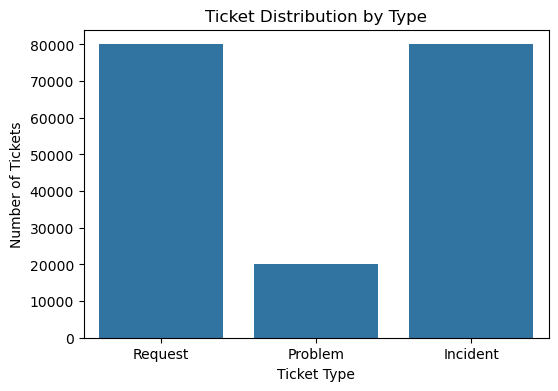

In [47]:
# Plot Ticket Type Distribution 
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Type')

plt.title('Ticket Distribution by Type')
plt.xlabel('Ticket Type')
plt.ylabel('Number of Tickets')

plt.show()

In [48]:
# Count tickets in each category
category_frequency = df["category"].value_counts()

print(category_frequency)

category
Feature Request              20169
Subscription Cancellation    20096
Performance Issue            20074
Security Concern             20040
Login Issue                  20002
Payment Problem              19997
Bug Report                   19981
Refund Request               19900
Data Sync Issue              19877
Account Suspension           19864
Name: count, dtype: int64


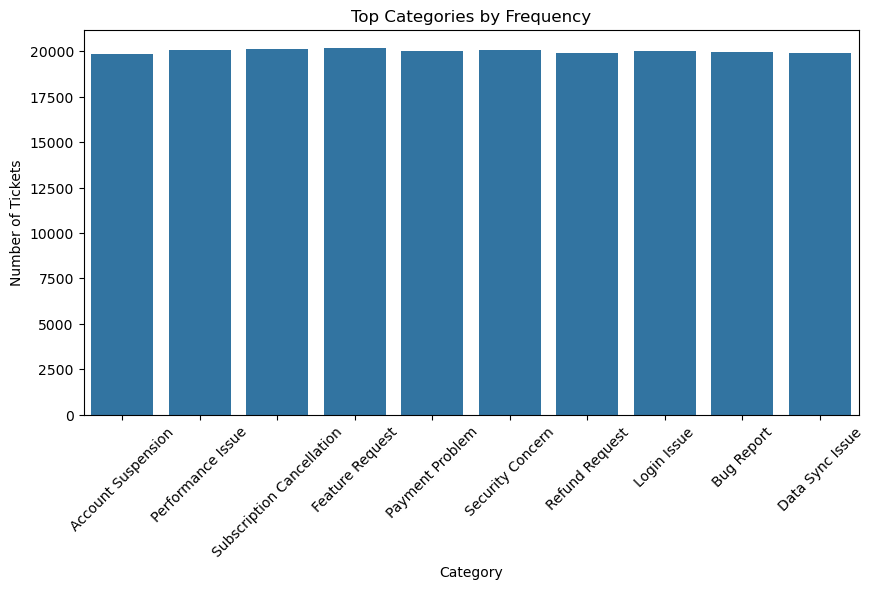

In [49]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="category")

plt.title("Top Categories by Frequency")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)

plt.show()

In [50]:
# Mapping Category to Queue

queue_mapping = {
    "Login Issue": "Technical Support",
    "Account Suspension": "Account Management",
    "Payment Problem": "Billing Support",
    "Refund Request": "Billing Support",
    "Security Concern": "Security Team",
    "Bug Report": "Development Team",
    "Performance Issue": "Infrastructure Team",
    "Feature Request": "Product Team",
    "Subscription Cancellation": "Account Management"
}

# Create Queue column
df["Queue"] = df["category"].map(queue_mapping)

# Check the result
df[["category", "Queue"]].head(10)

,category,Queue
0,Account Suspension,Account Management
1,Performance Issue,Infrastructure Team
2,Performance Issue,Infrastructure Team
3,Subscription Cancellation,Account Management
4,Feature Request,Product Team
5,Payment Problem,Billing Support
6,Security Concern,Security Team
7,Subscription Cancellation,Account Management
8,Security Concern,Security Team
9,Performance Issue,Infrastructure Team


In [51]:
df[df["Queue"].isna()]["category"].unique()

array(['Data Sync Issue'], dtype=object)

In [52]:
df.to_csv("customer_support_tickets_with_queue.csv", index=False)


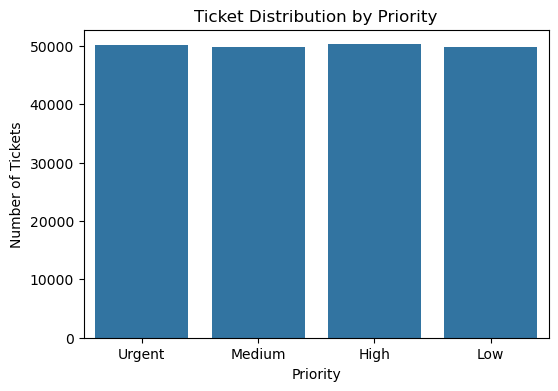

In [53]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="priority")

plt.title("Ticket Distribution by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")

plt.show()

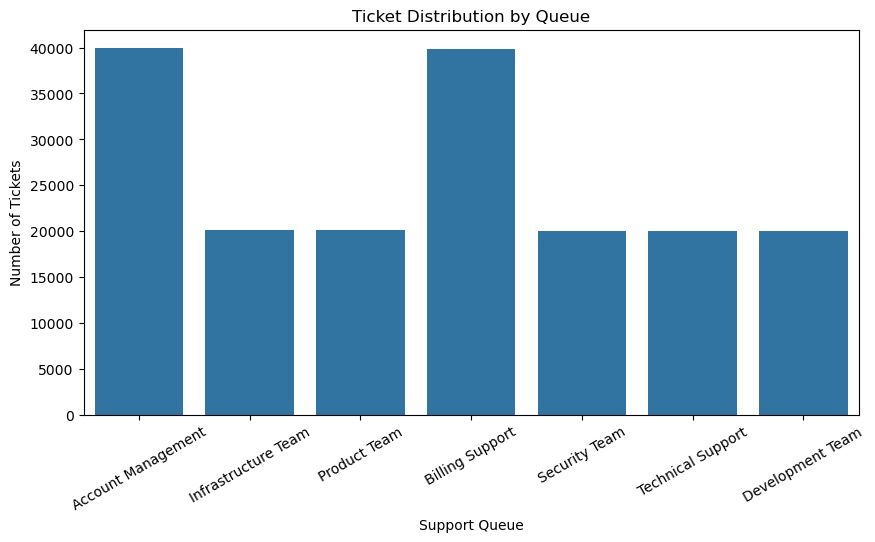

In [54]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Queue")

plt.title("Ticket Distribution by Queue")
plt.xlabel("Support Queue")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=30)

plt.show()

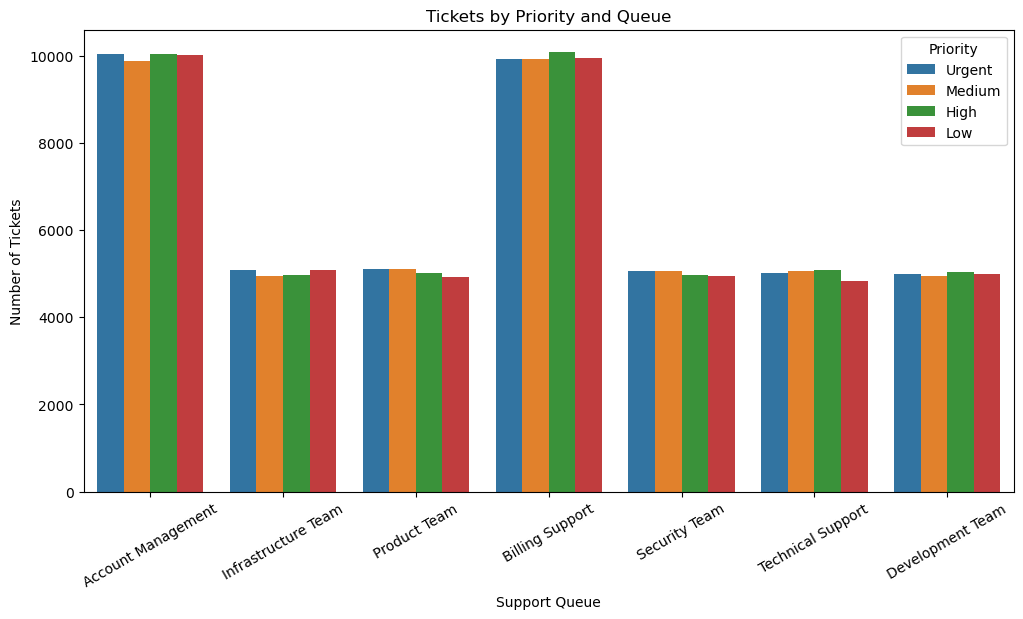

In [55]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Queue",
    hue="priority"
)

plt.title("Tickets by Priority and Queue")
plt.xlabel("Support Queue")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=30)

plt.legend(title="Priority")

plt.show()

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Take first 100000 tickets
sample_df = df.head(100000).copy()

# Fill missing values
sample_df["issue_description"] = sample_df["issue_description"].fillna("")

# Convert text to TF-IDF vectors
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

tfidf_matrix = vectorizer.fit_transform(sample_df["issue_description"])

# Calculate the average TF-IDF vector
mean_vector = tfidf_matrix.mean(axis=0)

# Convert sparse matrix to dense numpy array
mean_vector = np.asarray(mean_vector).reshape(1, -1)

# Calculate cosine similarity
similarity_scores = cosine_similarity(tfidf_matrix, mean_vector)

# Store as float values
sample_df["Similarity_Score"] = similarity_scores[:, 0].astype(float)

# Check the result
print(sample_df[["issue_description", "Similarity_Score"]].head(10))

# Check datatype
print(sample_df["Similarity_Score"].dtype)

                                   issue_description  Similarity_Score
0  The Payment Was Deducted From My Bank Account ...          0.344138
1  I Found A Bug In The Latest Update Affecting R...          0.308321
2  The Application Crashes Whenever I Try To Uplo...          0.304212
3  My Subscription Was Cancelled Without My Reque...          0.349366
4  The System Is Not Syncing Data Across Devices ...          0.307456
5  There Seems To Be A Discrepancy In My Billing ...          0.311688
6  I Would Like To Request A Refund For The Recen...          0.353134
7  Two-Factor Authentication Codes Are Not Being ...          0.308846
8  The Payment Was Deducted From My Bank Account ...          0.344138
9  I Am Unable To Access My Account After Enterin...          0.339423
float64


In [57]:
sample_df.to_csv("customer_support_tickets_100k_with_similarity.csv", index=False)

In [58]:
features = sample_df[[
    "category",
    "priority",
    "Queue",
    "Resolution_Duration",
    "Similarity_Score"
]]

In [59]:
features = features.copy()

features["category"] = features["category"].fillna("Unknown")
features["priority"] = features["priority"].fillna("Unknown")
features["Queue"] = features["Queue"].fillna("Unknown")

features["Resolution_Duration"] = features["Resolution_Duration"].fillna(
    features["Resolution_Duration"].median()
)

features["Similarity_Score"] = features["Similarity_Score"].fillna(
    features["Similarity_Score"].median()
)

In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            ["category", "priority", "Queue"]
        ),
        (
            "num",
            StandardScaler(),
            ["Resolution_Duration", "Similarity_Score"]
        )
    ]
)

X = preprocessor.fit_transform(features)

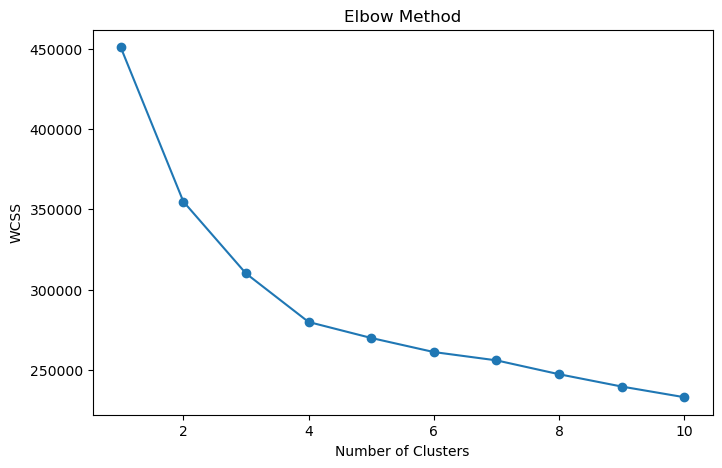

In [62]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [63]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

sample_df["Cluster"] = kmeans.fit_predict(X)

In [64]:
cluster_counts = sample_df["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    31958
1    18745
2    27933
3    21364
Name: count, dtype: int64


In [65]:
cluster_summary = sample_df.groupby("Cluster").agg({
    "Resolution_Duration": "mean",
    "Similarity_Score": "mean",
    "priority": lambda x: x.mode()[0],
    "category": lambda x: x.mode()[0],
    "Queue": lambda x: x.mode()[0]
})

print(cluster_summary)

         Resolution_Duration  Similarity_Score priority  \
Cluster                                                   
0                  10.501377          0.308390   Urgent   
1                   2.991998          0.346518     High   
2                   3.008306          0.308399   Urgent   
3                  10.513481          0.346535   Urgent   

                          category               Queue  
Cluster                                                 
0                      Login Issue  Account Management  
1                  Payment Problem     Billing Support  
2               Account Suspension  Account Management  
3        Subscription Cancellation  Account Management  


In [66]:
sample_df.to_csv(
    "customer_support_tickets_clustered.csv",
    index=False
)

In [67]:
avg_similarity = sample_df.groupby("Cluster")["Similarity_Score"].mean()

print(avg_similarity)

Cluster
0    0.308390
1    0.346518
2    0.308399
3    0.346535
Name: Similarity_Score, dtype: float64


Cluster
0    31958
1    18745
2    27933
3    21364
Name: count, dtype: int64


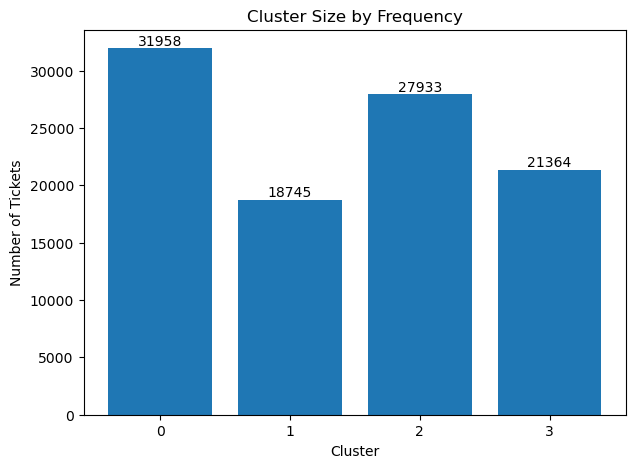

In [68]:
import matplotlib.pyplot as plt

# Count the number of tickets in each cluster
cluster_counts = sample_df["Cluster"].value_counts().sort_index()

print(cluster_counts)

# Plot
plt.figure(figsize=(7,5))

plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.title("Cluster Size by Frequency")
plt.xlabel("Cluster")
plt.ylabel("Number of Tickets")

# Show values on top of bars
for i, value in enumerate(cluster_counts.values):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()

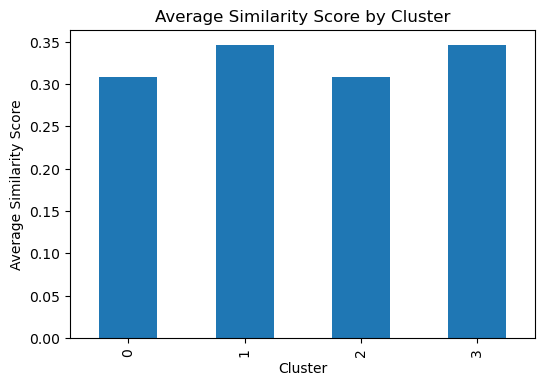

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

avg_similarity.plot(kind="bar")

plt.title("Average Similarity Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Similarity Score")

plt.show()

In [70]:
cluster_category = pd.crosstab(
    sample_df["Cluster"],
    sample_df["category"]
)

print(cluster_category)

category  Account Suspension  Bug Report  Data Sync Issue  Feature Request  \
Cluster                                                                      
0                       3167        3239             3070             3287   
1                       1857        1795             1858             1922   
2                       2862        2798             2788             2756   
3                       2042        2166             2150             2126   

category  Login Issue  Payment Problem  Performance Issue  Refund Request  \
Cluster                                                                     
0                3304             3130               3118            3188   
1                1822             1968               1943            1851   
2                2797             2769               2809            2748   
3                2100             2129               2160            2117   

category  Security Concern  Subscription Cancellation  
Cluster     

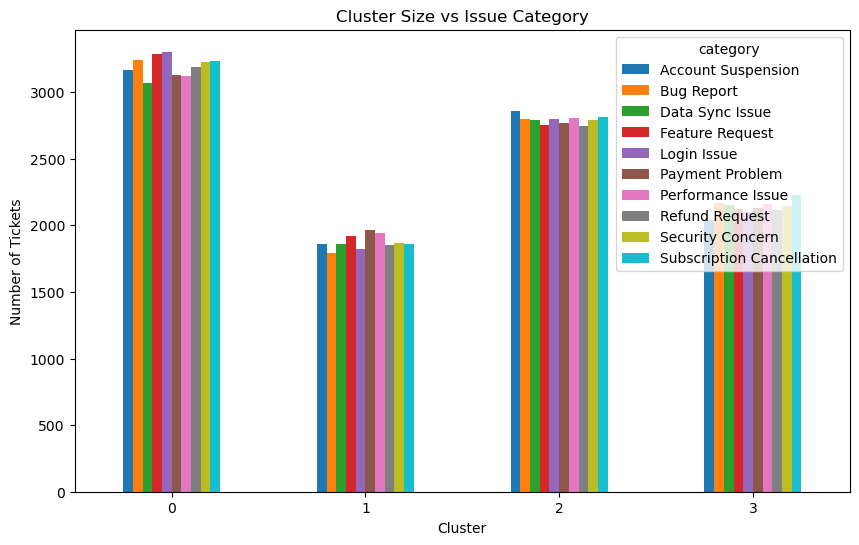

In [71]:
cluster_category.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Cluster Size vs Issue Category")
plt.xlabel("Cluster")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=0)

plt.show()

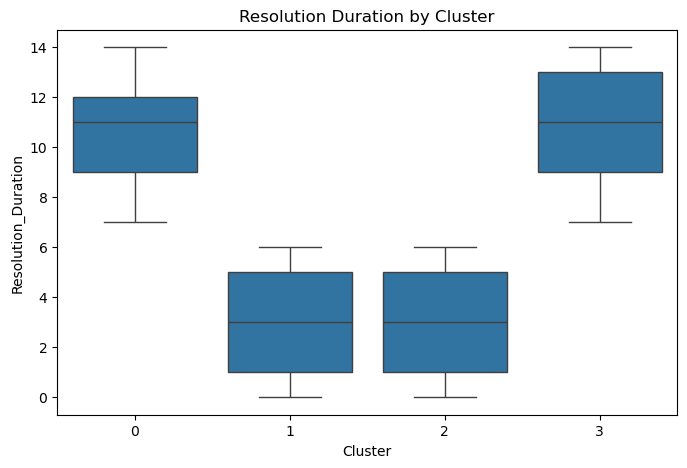

In [72]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=sample_df,
    x="Cluster",
    y="Resolution_Duration"
)

plt.title("Resolution Duration by Cluster")

plt.show()

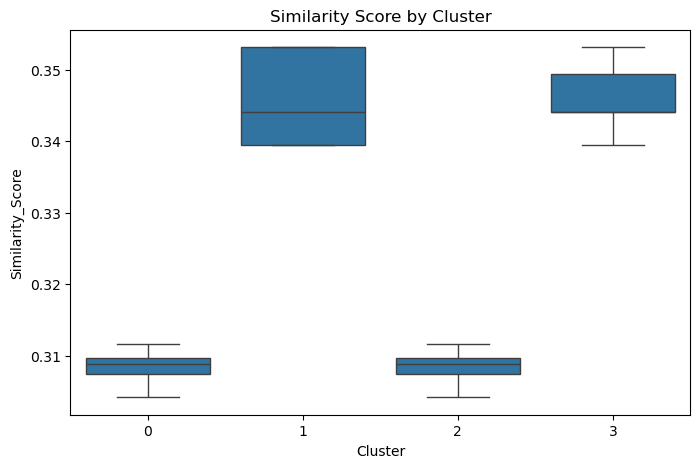

In [73]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=sample_df,
    x="Cluster",
    y="Similarity_Score"
)

plt.title("Similarity Score by Cluster")

plt.show()

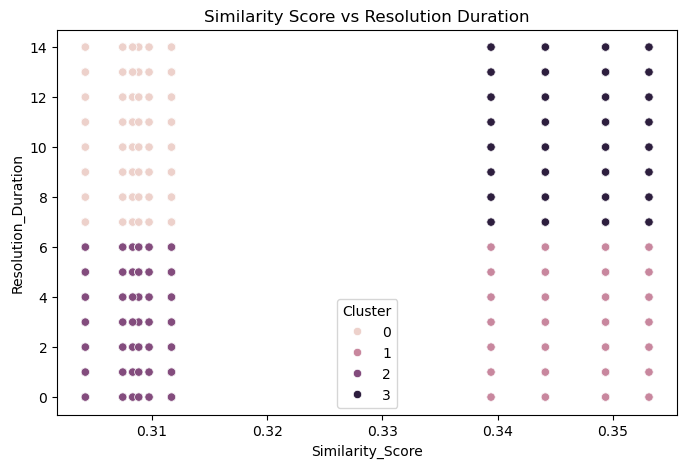

In [74]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=sample_df,
    x="Similarity_Score",
    y="Resolution_Duration",
    hue="Cluster"
)

plt.title("Similarity Score vs Resolution Duration")

plt.show()

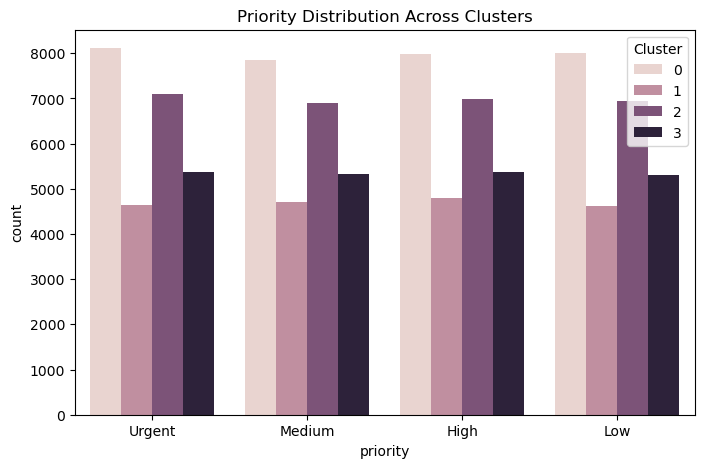

In [75]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=sample_df,
    x="priority",
    hue="Cluster"
)

plt.title("Priority Distribution Across Clusters")

plt.show()

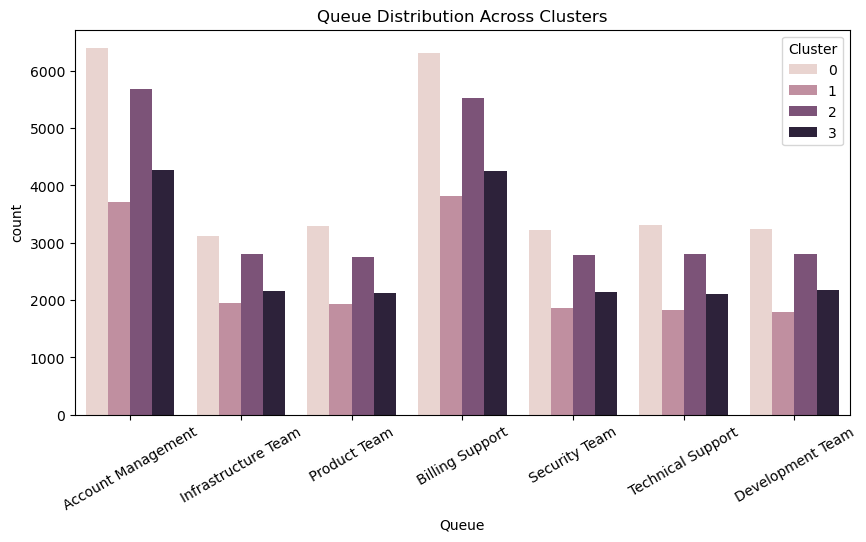

In [76]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=sample_df,
    x="Queue",
    hue="Cluster"
)

plt.xticks(rotation=30)

plt.title("Queue Distribution Across Clusters")

plt.show()

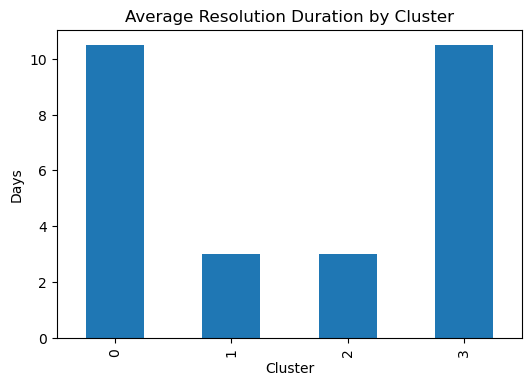

In [77]:
avg_resolution = sample_df.groupby("Cluster")["Resolution_Duration"].mean()

plt.figure(figsize=(6,4))

avg_resolution.plot(kind="bar")

plt.title("Average Resolution Duration by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Days")

plt.show()

In [78]:
summary = sample_df.groupby("Cluster").agg({

    "Similarity_Score":"mean",

    "Resolution_Duration":"mean",

    "category":lambda x:x.mode()[0],

    "priority":lambda x:x.mode()[0],

    "Queue":lambda x:x.mode()[0]

})

print(summary)

         Similarity_Score  Resolution_Duration                   category  \
Cluster                                                                     
0                0.308390            10.501377                Login Issue   
1                0.346518             2.991998            Payment Problem   
2                0.308399             3.008306         Account Suspension   
3                0.346535            10.513481  Subscription Cancellation   

        priority               Queue  
Cluster                               
0         Urgent  Account Management  
1           High     Billing Support  
2         Urgent  Account Management  
3         Urgent  Account Management  


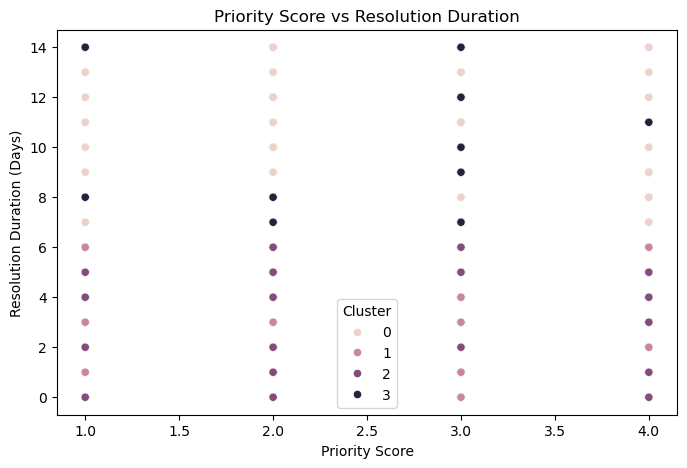

In [79]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=sample_df,
    x="Priority_Score",
    y="Resolution_Duration",
    hue="Cluster"
)

plt.title("Priority Score vs Resolution Duration")
plt.xlabel("Priority Score")
plt.ylabel("Resolution Duration (Days)")

plt.show()

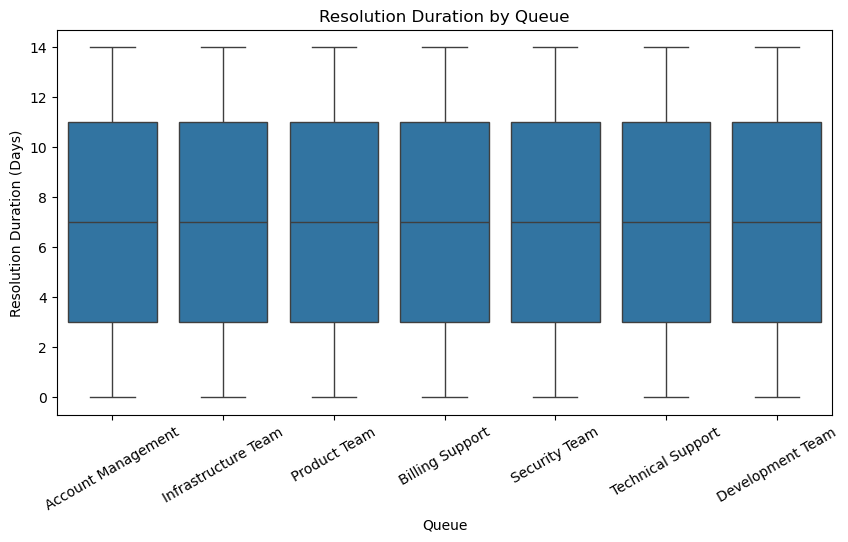

In [80]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=sample_df,
    x="Queue",
    y="Resolution_Duration"
)

plt.xticks(rotation=30)

plt.title("Resolution Duration by Queue")
plt.xlabel("Queue")
plt.ylabel("Resolution Duration (Days)")

plt.show()

In [81]:
# Calculate average resolution time by priority
priority_resolution = df.groupby("priority")["Resolution_Duration"].mean()

print(priority_resolution)


priority
High      7.004498
Low       7.007656
Medium    7.008184
Urgent    7.014199
Name: Resolution_Duration, dtype: float64


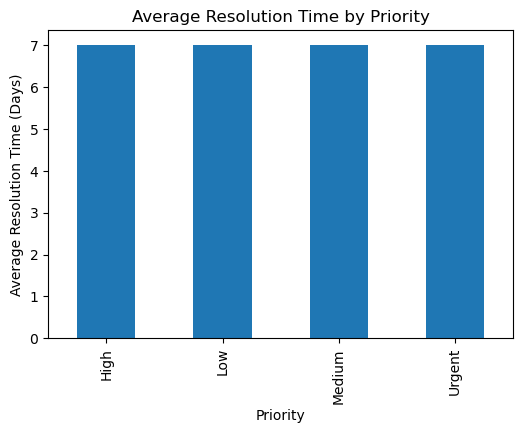

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

priority_resolution.plot(kind="bar")

plt.title("Average Resolution Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Average Resolution Time (Days)")

plt.show()

In [83]:
# Calculate average resolution time by type
type_resolution = df.groupby("Type")["Resolution_Duration"].mean()

print(type_resolution)

Type
Incident    7.008835
Problem     6.989589
Request     7.008934
Name: Resolution_Duration, dtype: float64


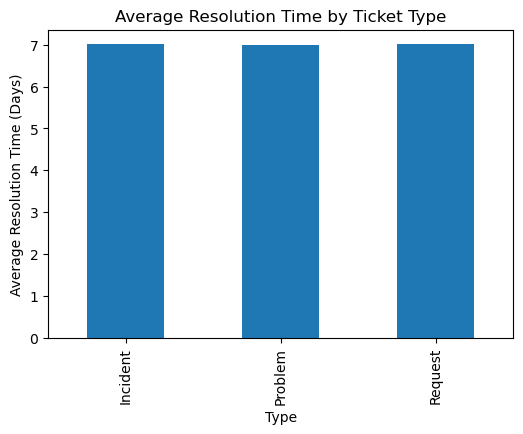

In [84]:
plt.figure(figsize=(6,4))

type_resolution.plot(kind="bar")

plt.title("Average Resolution Time by Ticket Type")
plt.xlabel("Type")
plt.ylabel("Average Resolution Time (Days)")

plt.show()

In [85]:
priority_type = df.pivot_table(
    values="Resolution_Duration",
    index="priority",
    columns="Type",
    aggfunc="mean"
)

print(priority_type)

Type      Incident   Problem   Request
priority                              
High      7.014452  6.920201  7.019543
Low       7.012276  7.017537  7.005866
Medium    6.983207  7.012735  7.005289
Urgent    7.025545  7.007091  7.004970


<Figure size 800x500 with 0 Axes>

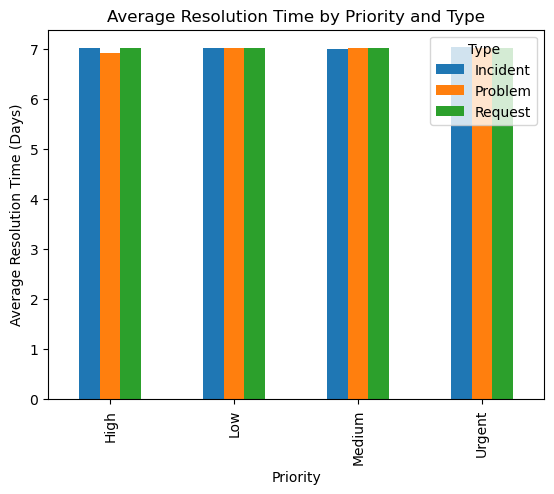

In [86]:
plt.figure(figsize=(8,5))

priority_type.plot(kind="bar")

plt.title("Average Resolution Time by Priority and Type")
plt.xlabel("Priority")
plt.ylabel("Average Resolution Time (Days)")

plt.legend(title="Type")

plt.show()

In [87]:
# Average resolution time by region
region_resolution = df.groupby("region")["Resolution_Duration"].mean().sort_values()

print(region_resolution)

region
North America    6.982367
Africa           6.989904
South America    6.996674
Asia             7.006586
Europe           7.032695
Australia        7.043968
Name: Resolution_Duration, dtype: float64


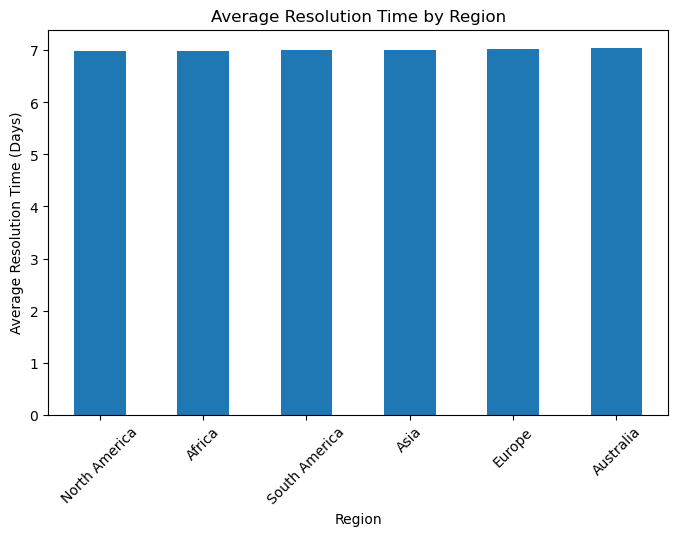

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

region_resolution.plot(kind="bar")

plt.title("Average Resolution Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Resolution Time (Days)")

plt.xticks(rotation=45)

plt.show()

In [89]:
queue_resolution = df.groupby("Queue")["Resolution_Duration"].mean().sort_values()

print(queue_resolution)

Queue
Infrastructure Team    6.989589
Technical Support      6.989801
Product Team           6.994943
Billing Support        7.000902
Account Management     7.015916
Development Team       7.023022
Security Team          7.029741
Name: Resolution_Duration, dtype: float64


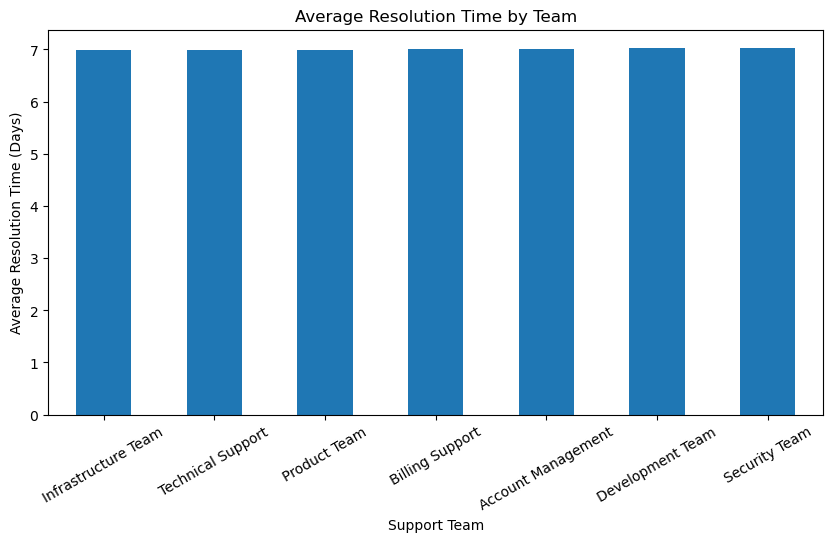

In [90]:
plt.figure(figsize=(10,5))

queue_resolution.plot(kind="bar")

plt.title("Average Resolution Time by Team")
plt.xlabel("Support Team")
plt.ylabel("Average Resolution Time (Days)")

plt.xticks(rotation=30)

plt.show()

In [91]:
fastest_team = queue_resolution.idxmin()
fastest_time = queue_resolution.min()

print("Fastest Team:", fastest_team)
print("Average Resolution Time:", round(fastest_time,2), "days")

Fastest Team: Infrastructure Team
Average Resolution Time: 6.99 days


In [92]:
fastest_region = region_resolution.idxmin()
fastest_time = region_resolution.min()

print("Fastest Region:", fastest_region)
print("Average Resolution Time:", round(fastest_time,2), "days")

Fastest Region: North America
Average Resolution Time: 6.98 days


In [93]:
print(df["status"].unique())

['Open' 'Closed' 'Pending Customer' 'In Progress' 'Resolved']


In [94]:
high_priority_unresolved = df[
    (df["priority"].isin(["High", "Urgent"])) &
    (df["status"].isin(["Open", "In Progress", "Pending"]))
]

print(high_priority_unresolved)

        ticket_id     customer_name                   customer_email  \
0               1    Patricia Smith    Patricia.Smith760@Outlook.Com   
13             14    Patricia Lopez    Patricia.Lopez799@Hotmail.Com   
14             15  Michael Gonzalez  Michael.Gonzalez337@Outlook.Com   
15             16       Susan Smith       Susan.Smith533@Hotmail.Com   
16             17    Michael Wilson    Michael.Wilson805@Hotmail.Com   
...           ...               ...                              ...   
199979     199980      Sarah Wilson      Sarah.Wilson978@Hotmail.Com   
199984     199985  Elizabeth Miller  Elizabeth.Miller713@Company.Com   
199986     199987    Jessica Miller    Jessica.Miller677@Hotmail.Com   
199990     199991       Susan Jones       Susan.Jones131@Hotmail.Com   
199992     199993    William Wilson      William.Wilson238@Yahoo.Com   

                    product                   category  \
0                Web Portal         Account Suspension   
13          Payment

In [95]:
print("Number of High-Priority Unresolved Tickets:",
      len(high_priority_unresolved))

Number of High-Priority Unresolved Tickets: 40133


In [96]:
print(high_priority_unresolved[
    [
        "ticket_id",
        "category",
        "priority",
        "status",
        "Queue",
        "Resolution_Duration"
    ]
].head(20))

    ticket_id                   category priority       status  \
0           1         Account Suspension   Urgent         Open   
13         14         Account Suspension   Urgent         Open   
14         15            Feature Request     High         Open   
15         16             Refund Request     High         Open   
16         17  Subscription Cancellation   Urgent  In Progress   
31         32           Security Concern   Urgent         Open   
34         35            Payment Problem   Urgent         Open   
35         36            Payment Problem   Urgent  In Progress   
38         39         Account Suspension     High  In Progress   
39         40             Refund Request   Urgent         Open   
40         41           Security Concern   Urgent         Open   
54         55          Performance Issue   Urgent  In Progress   
55         56            Feature Request   Urgent  In Progress   
60         61  Subscription Cancellation     High         Open   
64        

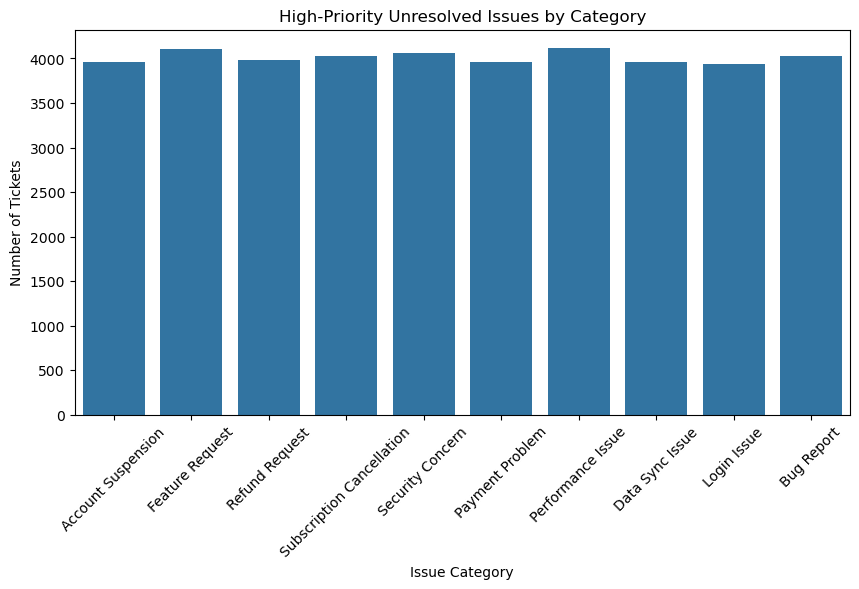

In [97]:

plt.figure(figsize=(10,5))

sns.countplot(
    data=high_priority_unresolved,
    x="category"
)

plt.title("High-Priority Unresolved Issues by Category")
plt.xlabel("Issue Category")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=45)

plt.show()

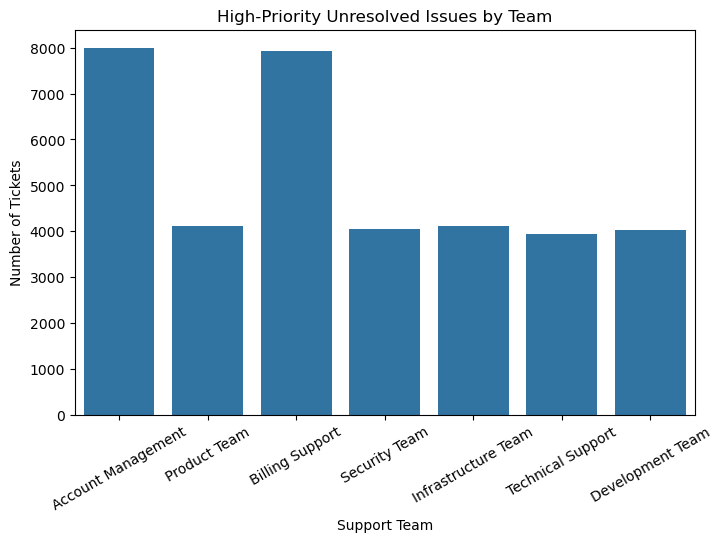

In [98]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=high_priority_unresolved,
    x="Queue"
)

plt.title("High-Priority Unresolved Issues by Team")
plt.xlabel("Support Team")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=30)

plt.show()

In [99]:
summary = high_priority_unresolved.groupby(["Queue", "category"]).size().reset_index(name="Count")

print(summary)

                 Queue                   category  Count
0   Account Management         Account Suspension   3965
1   Account Management  Subscription Cancellation   4031
2      Billing Support            Payment Problem   3957
3      Billing Support             Refund Request   3977
4     Development Team                 Bug Report   4026
5  Infrastructure Team          Performance Issue   4116
6         Product Team            Feature Request   4104
7        Security Team           Security Concern   4057
8    Technical Support                Login Issue   3941
